[2026-08-05 20:24:14] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 20:24:18] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 20:24:18] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-05 20:24:19] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-05 20:24:19] [info     ] ========== 数据检查 ==========
[2026-08-05 20:24:19] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_main', 'netflow_amount_rate_main', 'net_act

时段,IC
2024-01-15~2024-02-08,-0.0084
2024-09-24~2024-10-08,-0.0207

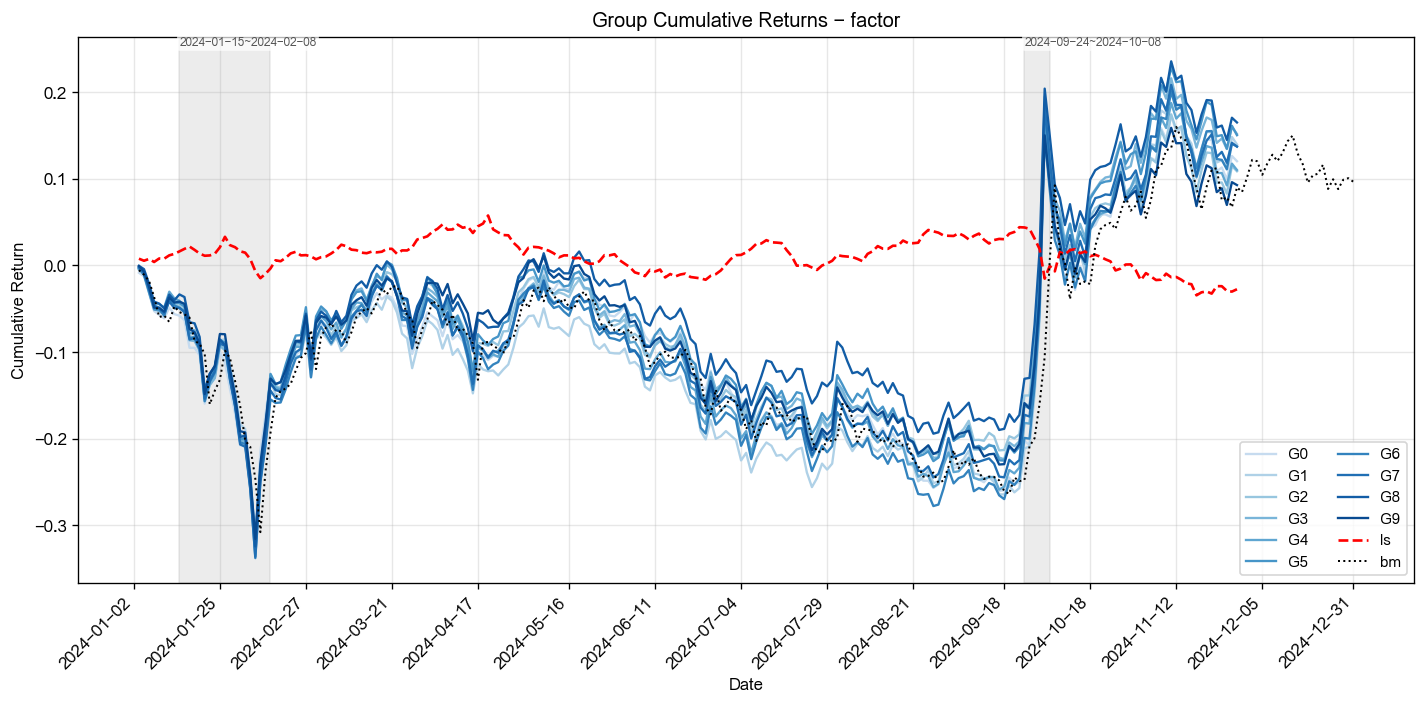
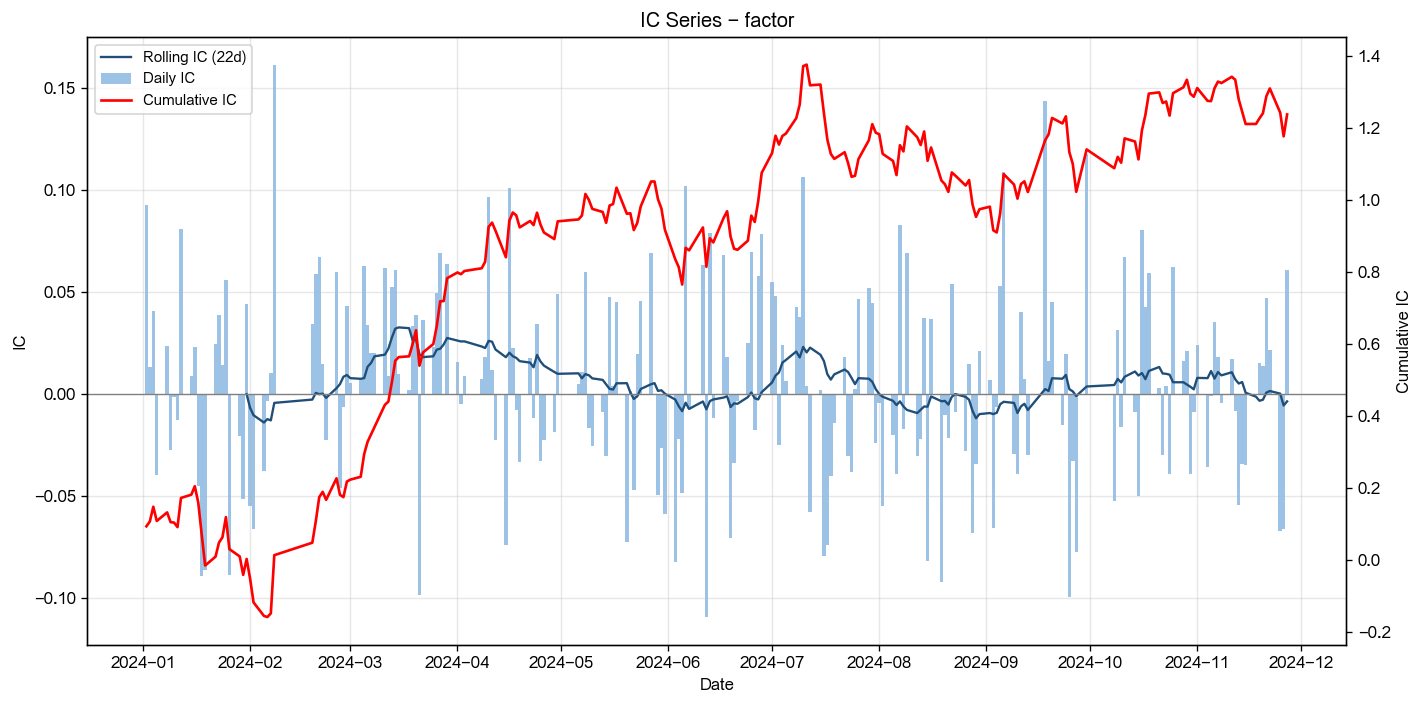
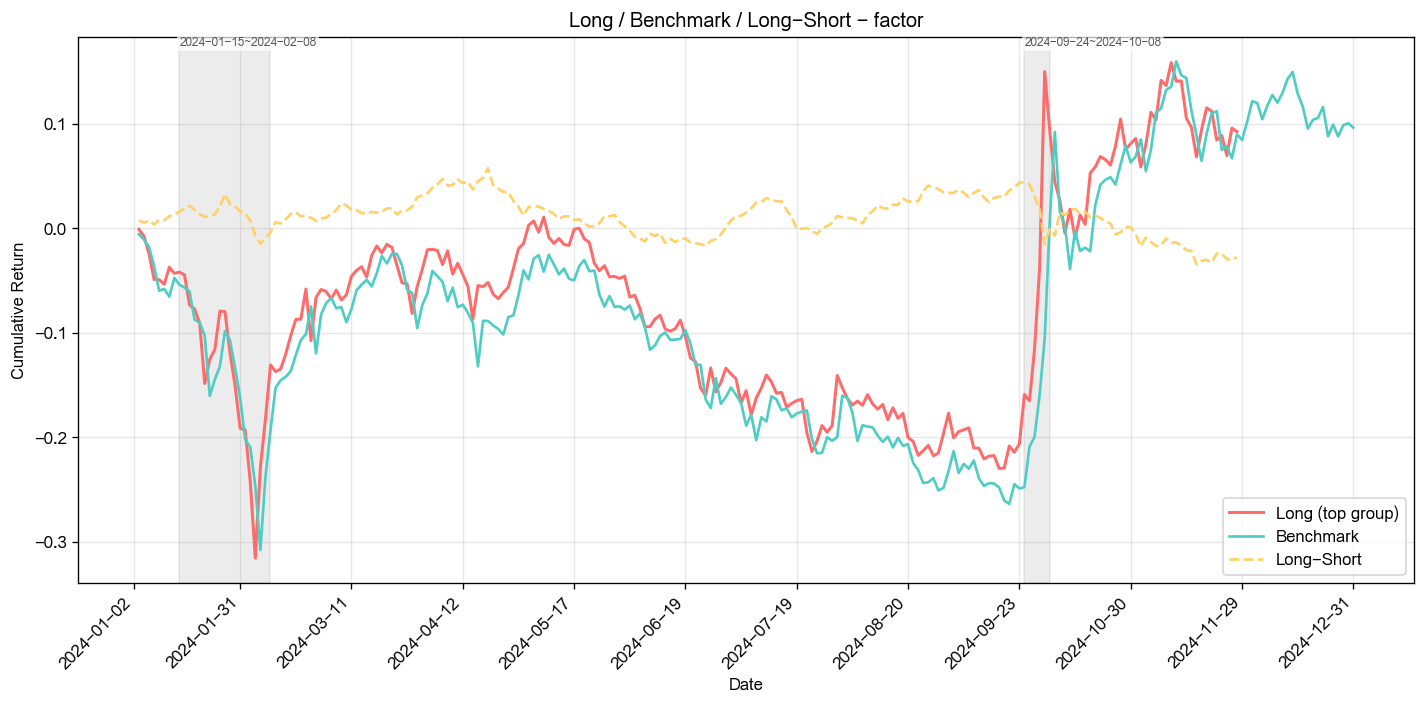
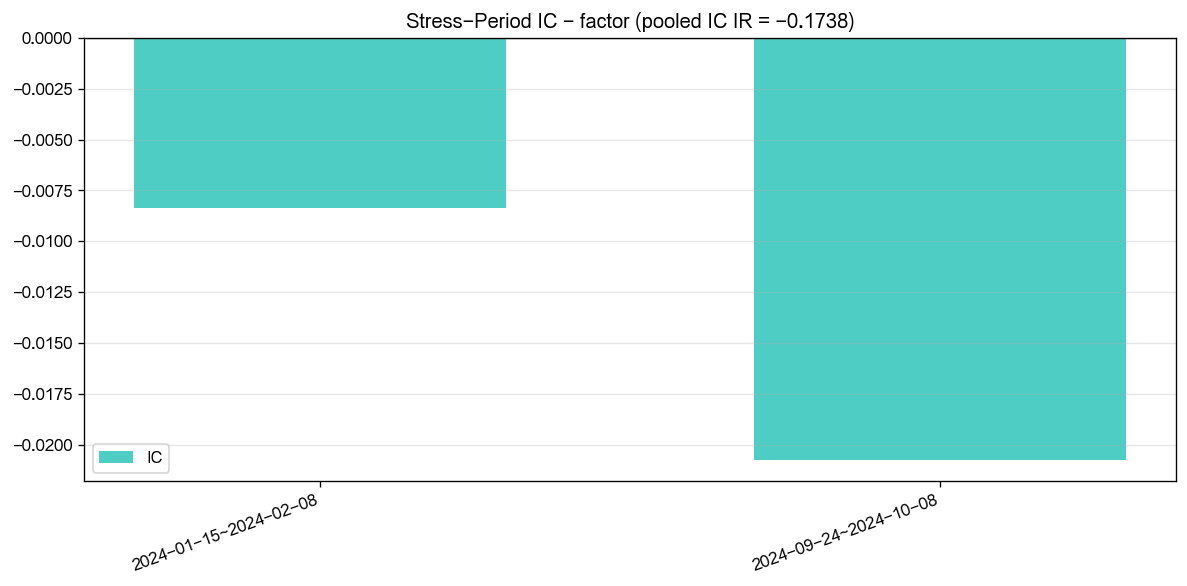
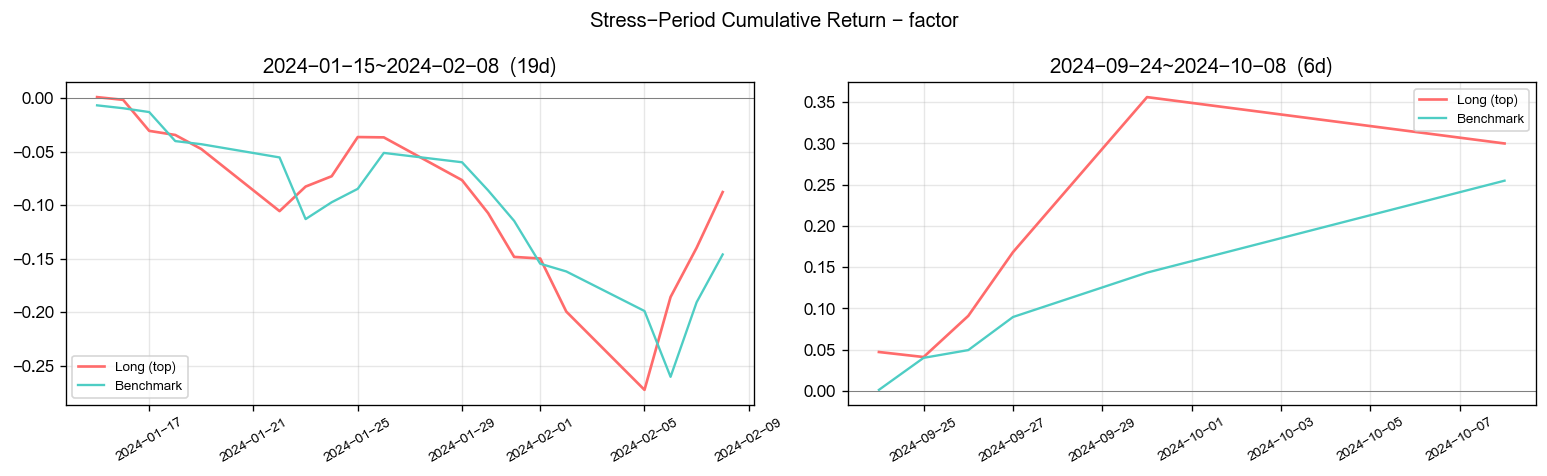

[2026-08-05 20:25:03] [info     ] ========== 因子池回归 ==========
[2026-08-05 20:25:04] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-05 20:25:05] [info     ] 获取收益率数据, 耗时: 1.9851 秒
[2026-08-05 20:25:06] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.7635 秒
[2026-08-05 20:25:06] [info     ] 统计 回归结果, 耗时: 0.0171 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9349,0.0447,0.0231,1.0000
2,amount,1.7206,0.0186,0.0108,1.0000
3,netflow_amount_rate_main,1.5412,0.0100,0.0065,1.0000
4,netflow_amount_main,1.5116,0.0252,0.0167,1.0000
5,gross_profit_rate_ttm,1.5003,0.0070,0.0046,1.0000
6,net_profit_rate_ttm,1.4405,0.0041,0.0028,0.8000
7,pb,1.4235,0.0097,0.0068,1.0000
8,bias_20,1.4153,0.0291,0.0206,0.9000
9,cci_14,1.3832,0.0338,0.0245,1.0000
10,ps_ttm,1.3481,0.0037,0.0027,0.9000

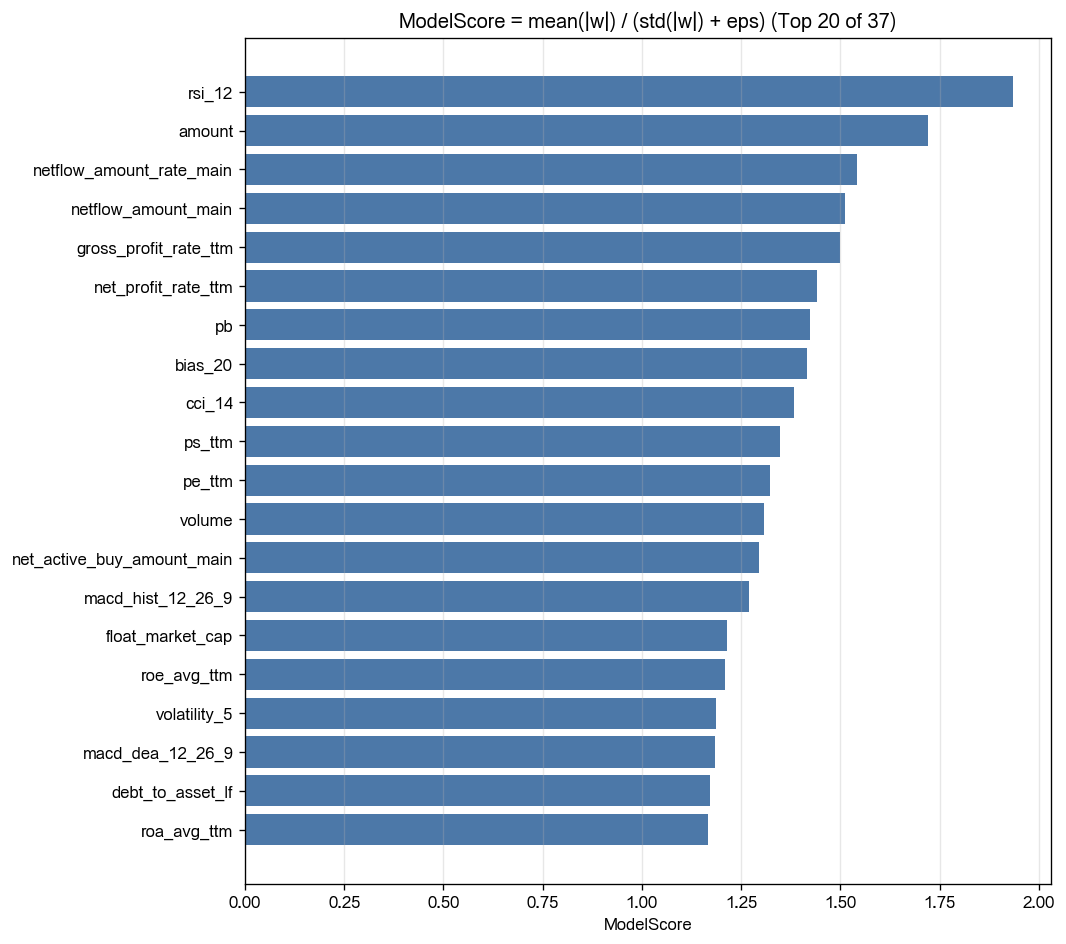
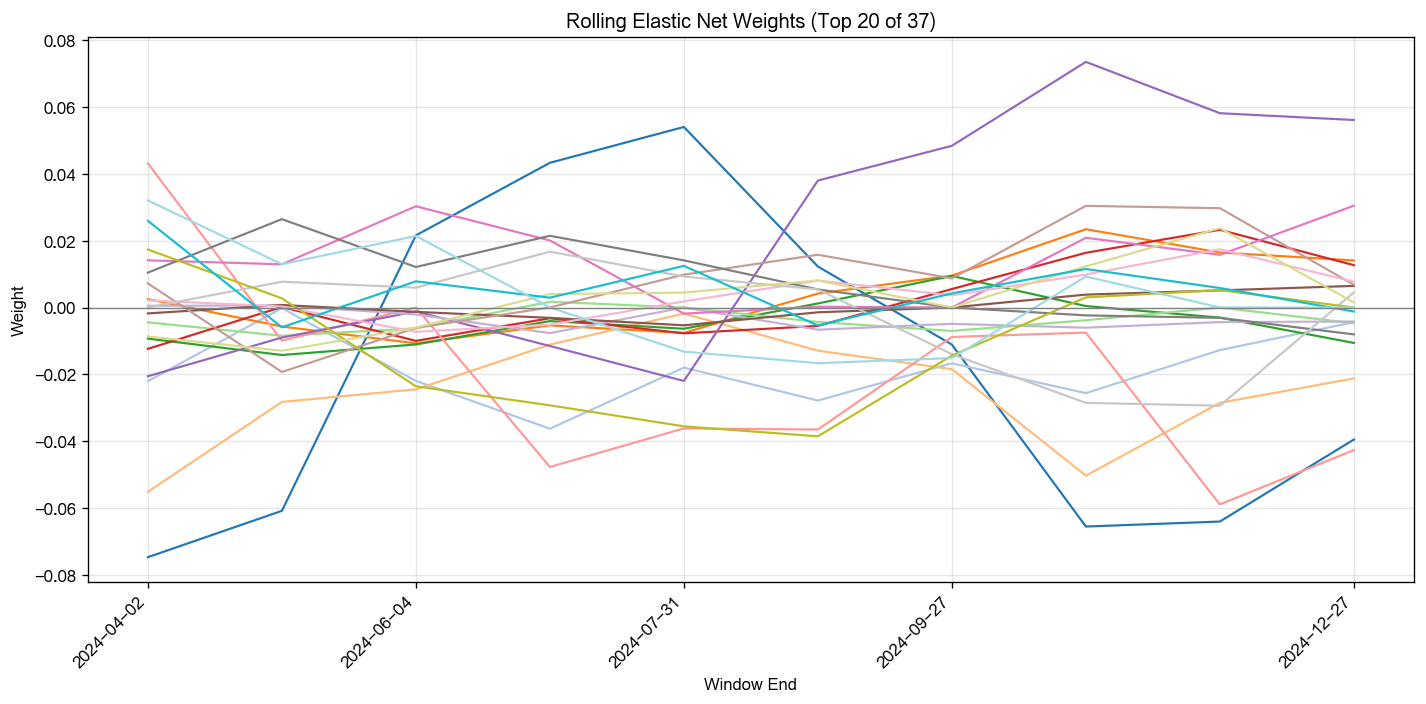
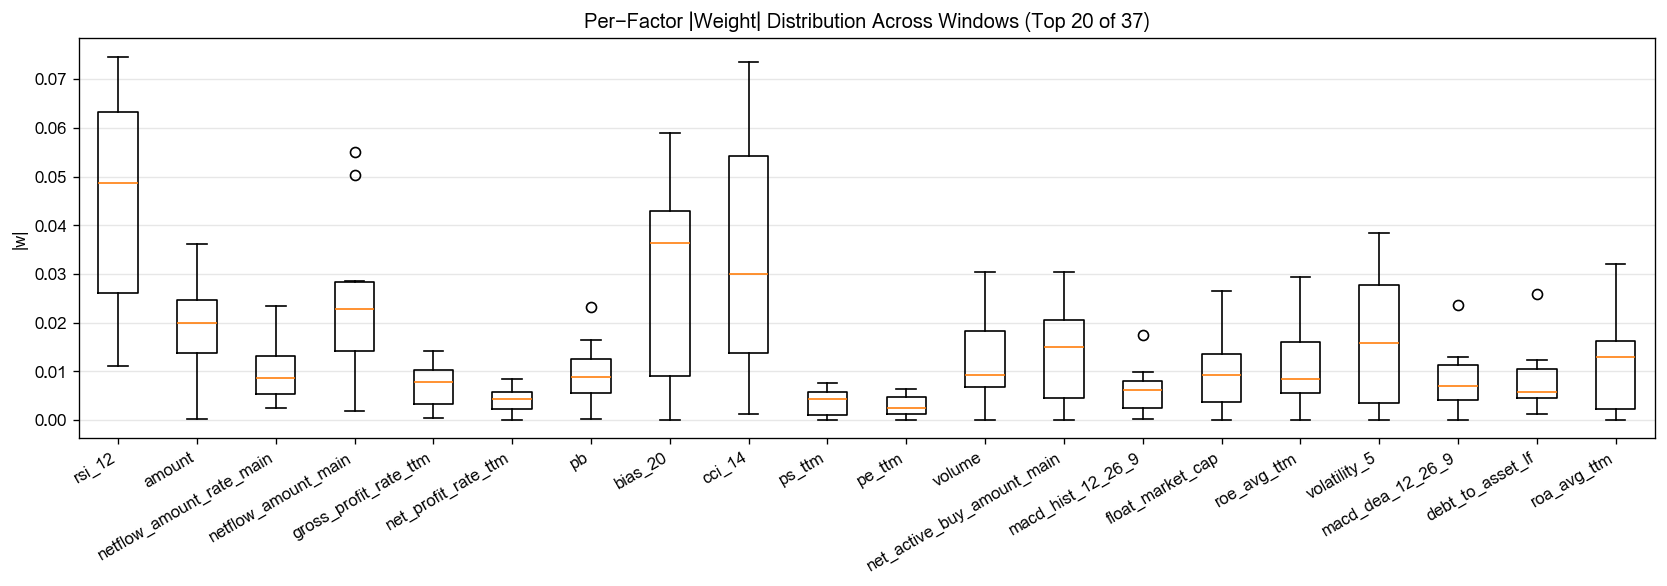
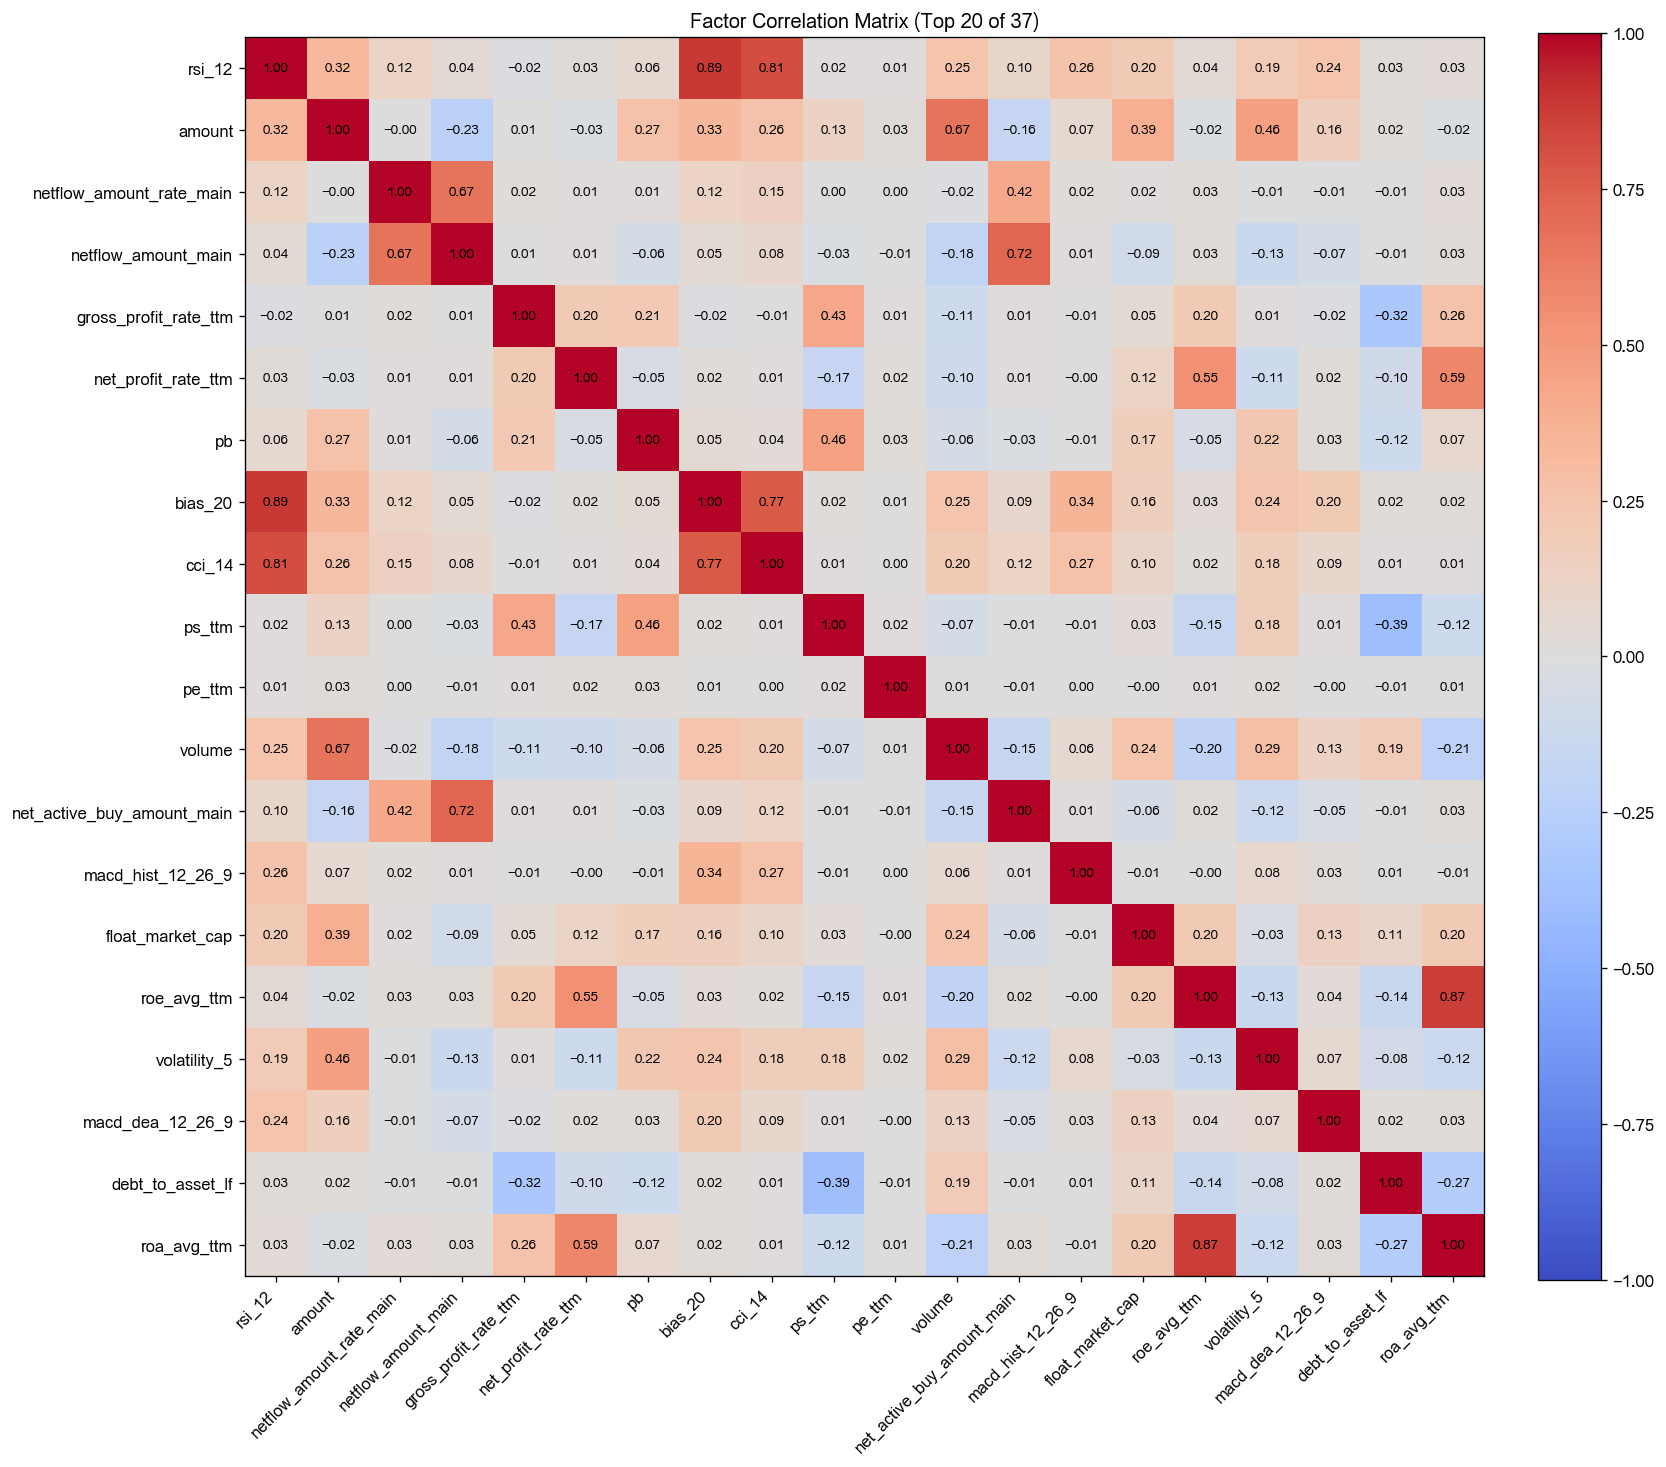

[2026-08-05 20:25:10] [warning  ] 返回的Outputs实例(size=35212896) 大于 64K, 将不会被缓存
[2026-08-05 20:25:10] [info     ] bigalpha_eval.v4 运行完成 [52.278s].


In [1]:
import dai
import numpy as np
import pandas as pd
from bigmodule import M

BINS = list(range(8))


def pattern_similarity(S, window=20, min_hist=10):
    """每日8维形态向量 与 过去window日平均形态(不含当日) 的相关系数"""
    n = len(S)
    out = np.full(n, np.nan)
    cs = np.cumsum(np.vstack([np.zeros((1, S.shape[1])), S]), axis=0)
    for i in range(n):
        s = max(0, i - window)
        if i - s < min_hist:
            continue
        typ = (cs[i] - cs[s]) / (i - s)
        a = S[i] - S[i].mean()
        b = typ - typ.mean()
        denom = np.sqrt((a * a).sum() * (b * b).sum())
        if denom > 0:
            out[i] = (a * b).sum() / denom
    return out


def main(datasources, start_date, end_date):
    bar1m_table = datasources['bar1m']

    sd = pd.to_datetime(start_date) - pd.Timedelta(days=60)
    ed = pd.to_datetime(end_date)

    # 每30分钟一个时段：9:30-11:30 四段(bin0-3)，13:00-15:00 四段(bin4-7)
    sql = """
    WITH t AS (
        SELECT date::DATE::DATETIME AS date,
               instrument,
               DATE_PART('hour', date) * 60 + DATE_PART('minute', date) AS tmin,
               CAST(volume AS DOUBLE) AS vol
        FROM {bar1m_table}
    ),
    b AS (
        SELECT date, instrument,
               CASE WHEN tmin < 600 THEN 0 WHEN tmin < 630 THEN 1
                    WHEN tmin < 660 THEN 2 WHEN tmin < 690 THEN 3
                    WHEN tmin < 780 THEN -1
                    WHEN tmin < 810 THEN 4 WHEN tmin < 840 THEN 5
                    WHEN tmin < 870 THEN 6 ELSE 7 END AS bin,
               vol
        FROM t
        WHERE tmin >= 570
    )
    SELECT date, instrument, bin, SUM(vol) AS v
    FROM b
    WHERE bin >= 0
    GROUP BY date, instrument, bin
    """.format(bar1m_table=bar1m_table)

    bounds = [b for b in pd.date_range(sd, ed, freq='MS') if b > sd]
    bounds = [sd] + bounds + [ed + pd.Timedelta(seconds=1)]
    dfs = []
    for i in range(len(bounds) - 1):
        cs_, ce = bounds[i], bounds[i + 1] - pd.Timedelta(seconds=1)
        dfs.append(dai.query(
            sql,
            filters={'date': [cs_.strftime('%Y-%m-%d %H:%M:%S'),
                              ce.strftime('%Y-%m-%d %H:%M:%S')]}
        ).df())
    df = pd.concat(dfs, ignore_index=True)

    # 透视成 (date, instrument) × 8时段，转成成交量占比（形态向量）
    wide = df.pivot_table(index=['date', 'instrument'], columns='bin',
                          values='v', aggfunc='sum').fillna(0)
    wide = wide.reindex(columns=BINS, fill_value=0)
    # 覆盖防御：当天有效时段<6（如9/27宕机）整日剔除
    wide = wide[(wide > 0).sum(axis=1) >= 6]
    share = wide.div(wide.sum(axis=1), axis=0).reset_index()
    share = share.sort_values(['instrument', 'date']).reset_index(drop=True)

    # 每日形态复制度 → 10日平滑
    def _calc(g):
        S = g[BINS].to_numpy(dtype=float)
        sim = pattern_similarity(S)
        return pd.Series(sim, index=g.index)

    share['sim'] = share.groupby('instrument', group_keys=False).apply(_calc)
    share['factor'] = share.groupby('instrument')['sim'].transform(
        lambda s: s.rolling(10, min_periods=5).mean()
    )

    df = share[share['date'] >= pd.to_datetime(start_date)]

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]}
    ).df()
    df = pd.merge(df[['date', 'instrument', 'factor']], stk_pool,
                  how='right', on=['date', 'instrument'])
    df['factor'] = df['factor'].replace([np.inf, -np.inf], np.nan)

    return df[['date', 'instrument', 'factor']]


if __name__ == '__main__':
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'
    factor_data = main(datasources, start_date, end_date)
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]}
    ).df()
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True
    )